# 03. Unified Hybrid Pipeline - Quality Defect Explainability

This notebook has been refactored for clarity. It integrates directly with `grader.py` and the `defect_profiles.py` and `ripeness_profile.py`  dictionary from the AI Engine.

In [6]:
# ==========================================
# CELL 1: ALL IMPORTS
# ==========================================
import sys
import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
from pathlib import Path
from ultralytics import YOLO

# XAI Libraries
from pytorch_grad_cam import EigenCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

print("Libraries imported successfully.")

Libraries imported successfully.


In [7]:
# ==========================================
# CELL 2: PATHS & INITIALIZATION
# ==========================================
PROJECT_ROOT = Path("..").resolve()

# Add paths to import from apps
sys.path.append(str(PROJECT_ROOT))
sys.path.append(str(PROJECT_ROOT / "apps" / "ai_engine" / "grading"))

# Import new Grader Pipeline
from grader import QualityGrader

# Model Path
MODEL_WEIGHTS = PROJECT_ROOT / "ai_models" / "grading" / "weights" / "fruit_disease_v2" / "weights" / "best.pt"

# Initialize AI
detector = YOLO(str(MODEL_WEIGHTS))
grader = QualityGrader()

# Manual test image directory
TEST_IMG_DIR = PROJECT_ROOT / 'notebooks' / "dataset" / "test_images"

print("\nAI Architectures Initialized:")
print(f"- YOLO Model: {MODEL_WEIGHTS.name}")
print(f"- Hybrid Grader: Active")
print(f"- Test Image Dir: {TEST_IMG_DIR}")


AI Architectures Initialized:
- YOLO Model: best.pt
- Hybrid Grader: Active
- Test Image Dir: D:\in-class\Distributed and enterprise software development\project\DESD_Group3\notebooks\dataset\test_images


In [8]:
# ==========================================
# CELL 3: PIPELINE EXECUTION FUNCTION
# ==========================================
class YoloModelWrapper(torch.nn.Module):
    """
    Wrapper to make YOLOv10 compatible with pytorch-grad-cam.
    Ensures the forward pass returns a tensor instead of a tuple.
    """
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        # YOLOv10 forward pass returns a tuple/list
        # We return only the first element (the predictions tensor)
        results = self.model(x)
        if isinstance(results, (list, tuple)):
            return results[0]
        return results

def get_yolo_xai_data(results):
    """
    [METHOD 1] Inherent Explainability: Extracting boxes, confidence and labels.
    """
    xai_data = []
    for r in results:
        boxes = r.boxes
        for box in boxes:
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            confidence = round(box.conf[0].item() * 100, 2)
            class_id = int(box.cls[0].item())
            class_name = r.names[class_id]

            xai_data.append({
                "class": class_name,
                "confidence": f"{confidence}%",
                "bbox": [int(x1), int(y1), int(x2), int(y2)]
            })
    return xai_data

def generate_yolo_heatmap(model, img_rgb, target_layer_idx=-2):
    """
    [METHOD 2] Heatmap Visualization using EigenCAM.
    Uses YoloModelWrapper for compatibility.
    """
    try:
        # 1. Wrap the model
        wrapped_model = YoloModelWrapper(model.model)
        wrapped_model.eval()

        # 2. Define Target Layer (C2fCIB block before head)
        target_layers = [model.model.model[target_layer_idx]]

        # 3. Device Detection
        device = next(model.model.parameters()).device

        # 4. Preprocess image
        img_resized = cv2.resize(img_rgb, (640, 640))
        input_tensor = torch.from_numpy(img_resized).permute(2, 0, 1).unsqueeze(0).float() / 255.0
        input_tensor = input_tensor.to(device)

        # 5. Initialize EigenCAM with Wrapped Model
        cam = EigenCAM(model=wrapped_model, target_layers=target_layers)

        # 6. Generate grayscale cam
        grayscale_cam = cam(input_tensor=input_tensor)[0, :]

        # 7. Overlay on original image
        rgb_norm = img_resized / 255.0
        cam_image = show_cam_on_image(rgb_norm, grayscale_cam, use_rgb=True)

        return cam_image
    except Exception as e:
        print(f"[XAI WARNING] Heatmap generation failed: {e}")
        return None

def analyze_fruit_quality(image_path_str):
    """
    Enhanced end-to-end pipeline with XAI.
    """
    img_path = Path(image_path_str)
    if not img_path.exists():
        print(f"[ERROR] File does not exist: {img_path}")
        return

    print(f"\n{'='*50}\nAnalyzing: {img_path.name}\n{'='*50}")

    image = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    results = detector.predict(source=image, conf=0.25, verbose=False)

    yolo_xai_report = get_yolo_xai_data(results)

    boxes = results[0].boxes
    if len(boxes) == 0:
        print("No object detected!")
        plt.imshow(img_rgb)
        plt.axis('off')
        plt.show()
        return

    bbox = boxes[0].xyxy[0].cpu().numpy().astype(int).tolist()
    class_id = int(boxes[0].cls[0].item())
    class_name = detector.names[class_id]

    print(f"[YOLO XAI Info]: {yolo_xai_report[0]}")

    # CV Processing
    ih, iw = image.shape[:2]
    pad_x, pad_y = int((bbox[2]-bbox[0])*0.15), int((bbox[3]-bbox[1])*0.15)
    x1, y1 = max(0, bbox[0]-pad_x), max(0, bbox[1]-pad_y)
    x2, y2 = min(iw, bbox[2]+pad_x), min(ih, bbox[3]+pad_y)
    cropped_fruit = image[y1:y2, x1:x2]

    safe_class_name = class_name.replace("__", "_")
    grader_report, highlighted_img = grader.process_fruit(cropped_fruit, safe_class_name)

    print(f"Detected Class : {class_name}")
    print(f"Final Verdict  : {grader_report['decision']['grade']}")
    print(f"Reasons        : {grader_report['decision']['reasons']}")

    # --- HEATMAP XAI ---
    condition = safe_class_name.split('_')[1]
    heatmap_img = None
    if condition == 'Rotten':
        heatmap_img = generate_yolo_heatmap(detector, img_rgb)

    # --- VISUALIZATION ---
    if condition == 'Healthy':
        fig, ax = plt.subplots(1, 1, figsize=(7, 6))
        fig.suptitle(f"[{class_name}] Result: {grader_report['decision']['grade']}", fontsize=14, fontweight='bold')
        ax.imshow(cv2.cvtColor(cropped_fruit, cv2.COLOR_BGR2RGB))
        ax.set_title("AI Crop (YOLO)")
        ax.axis('off')
    else:
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        fig.suptitle(f"[{class_name}] XAI DIAGNOSTIC: {grader_report['decision']['grade']}", fontsize=16, fontweight='bold', color='red')

        axes[0].imshow(cv2.cvtColor(cropped_fruit, cv2.COLOR_BGR2RGB))
        axes[0].set_title("1. AI Crop (YOLO)", fontsize=12)
        axes[0].axis('off')

        if heatmap_img is not None:
            axes[1].imshow(heatmap_img)
            axes[1].set_title("2. YOLO XAI Heatmap", fontsize=12, color='darkred')
        else:
            axes[1].text(0.5, 0.5, 'Heatmap Error', ha='center')
            axes[1].axis('off')

        axes[2].imshow(cv2.cvtColor(highlighted_img, cv2.COLOR_BGR2RGB))
        axes[2].set_title("3. CV Cross-Check", fontsize=12)
        axes[2].axis('off')

    plt.tight_layout()
    plt.show()

print("Enhanced Pipeline function fixed with YoloModelWrapper.")

Enhanced Pipeline function fixed with YoloModelWrapper.


# Automated Random Test
Use the cell below to run automated tests on dataset images.


Analyzing: rotated_by_75_Screen Shot 2018-06-07 at 2.38.28 PM.png
[YOLO XAI Info]: {'class': 'Apple__Rotten', 'confidence': '87.22%', 'bbox': [44, 21, 180, 165]}
Detected Class : Apple__Rotten
Final Verdict  : Grade F (Rotten/Defective)
Reasons        : ['Discarded: YOLO classified as Rotten. CV analysis verified defect area.']


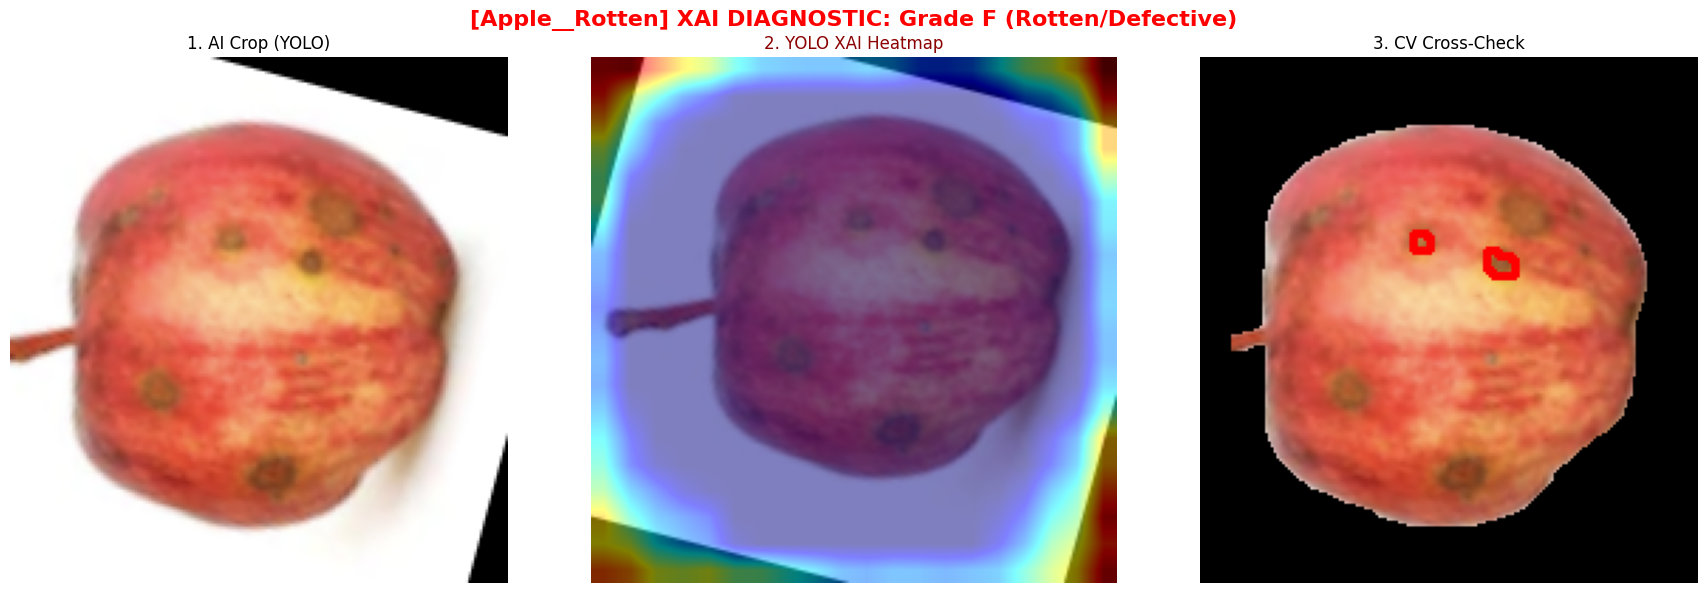


Analyzing: vertical_flip_Screen Shot 2018-06-12 at 11.37.52 PM.png
[YOLO XAI Info]: {'class': 'Orange__Rotten', 'confidence': '95.62%', 'bbox': [44, 24, 338, 317]}
Detected Class : Orange__Rotten
Final Verdict  : Grade F (Rotten/Defective)
Reasons        : ['Discarded: YOLO classified as Rotten. CV analysis verified defect area.']


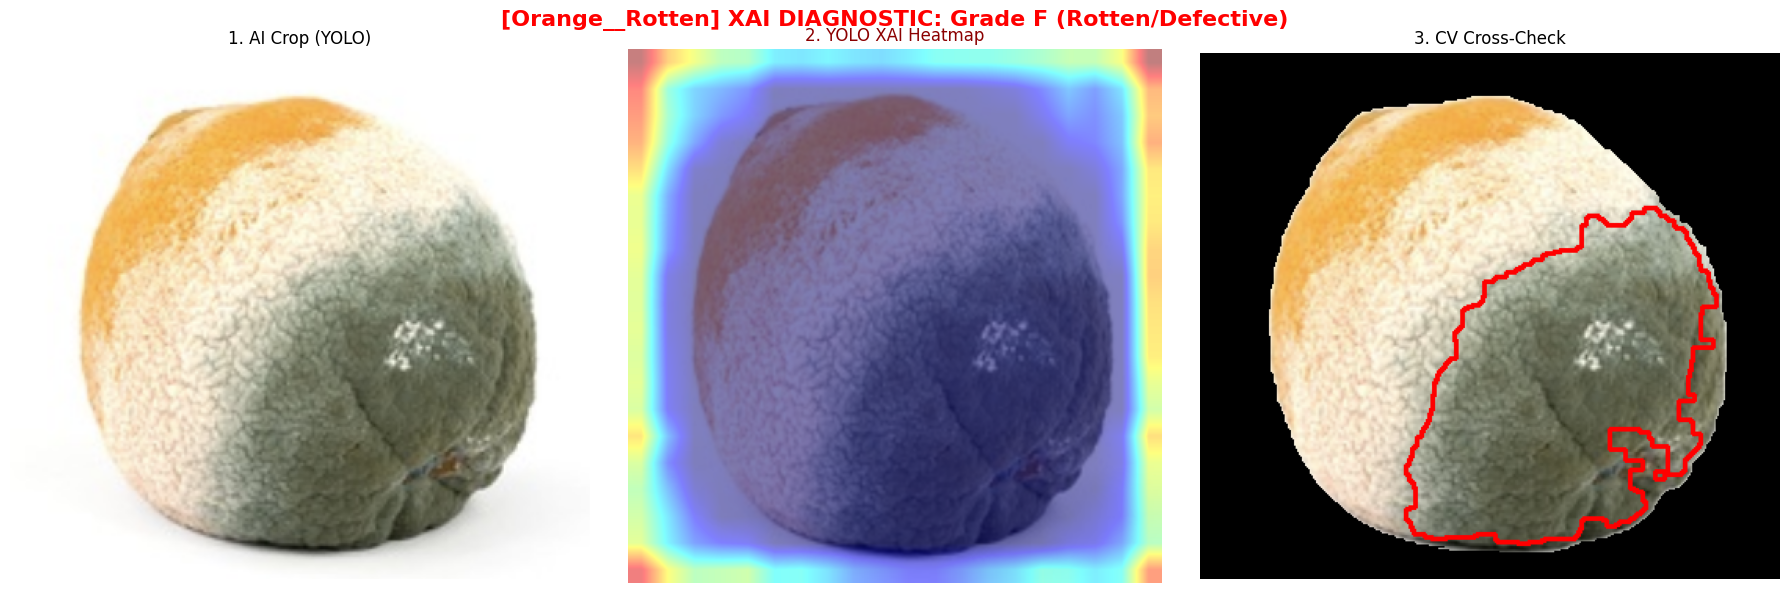

In [9]:
import random
import os

# List all images in test folder
test_files = [str(f) for f in TEST_IMG_DIR.glob("*.png")]
if test_files:
    sample_img = random.choice(test_files)
    analyze_fruit_quality(sample_img)
else:
    print("No test images found in dataset/test_images/")

# Manual Test (Chy th cng)
in ng dn nh ca bn vo bin `my_test_image` bn di v chy cell  xem kt qu.


Analyzing: tao_hong_1.jpg
[YOLO XAI Info]: {'class': 'Apple__Rotten', 'confidence': '76.59%', 'bbox': [51, 47, 319, 319]}
Detected Class : Apple__Rotten
Final Verdict  : Grade F (Rotten/Defective)
Reasons        : ['Discarded: YOLO classified as Rotten. CV analysis verified defect area.']


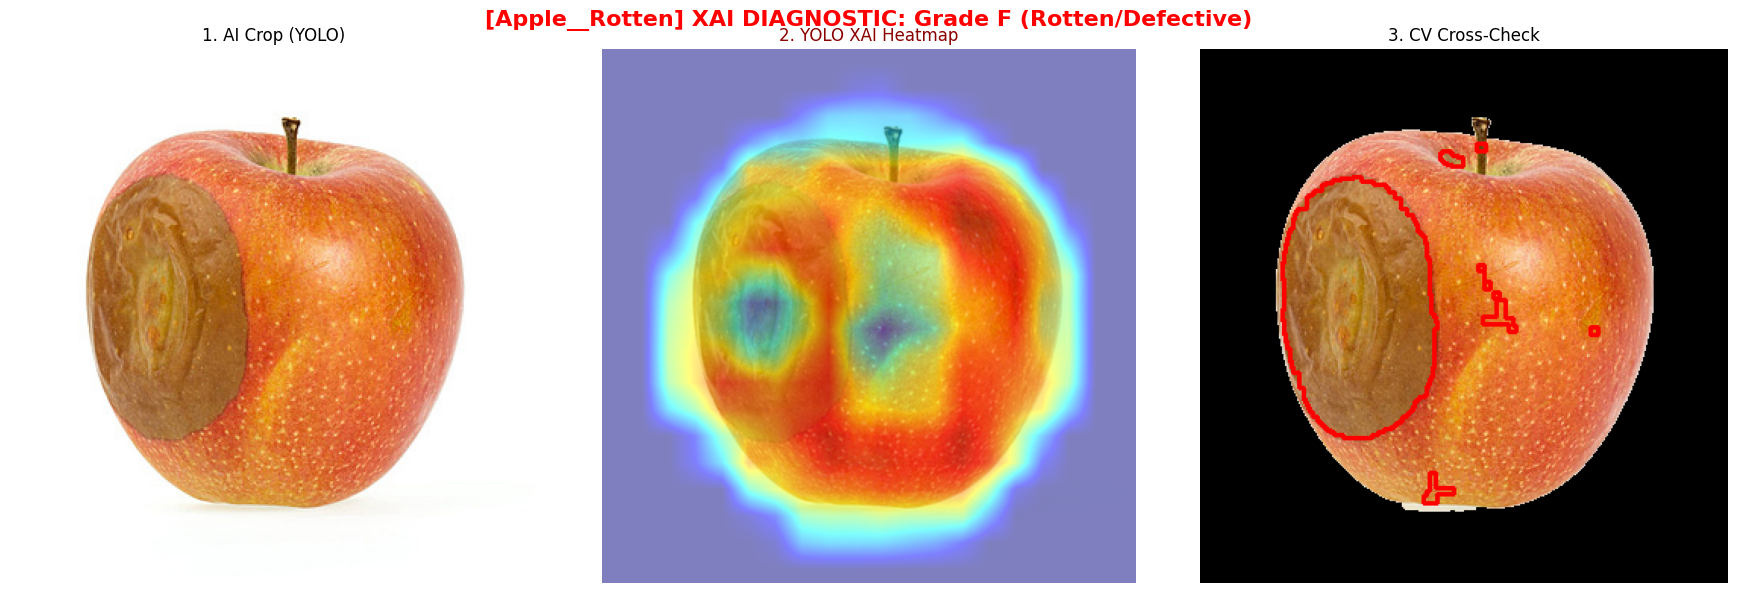

In [ ]:
# ==========================================
# CELL 5: MANUAL TEST
# ==========================================
# You can change the image filename here:
my_test_image = TEST_IMG_DIR / "apple_rotten_1.jpg" # (Example: your image filename)

if my_test_image.exists():
    analyze_fruit_quality(str(my_test_image))
else:
    print(f"[ERROR] File does not exist: {my_test_image}")
    print(f"Please copy the image to the {TEST_IMG_DIR} directory or change the path directly.")